### Question 1

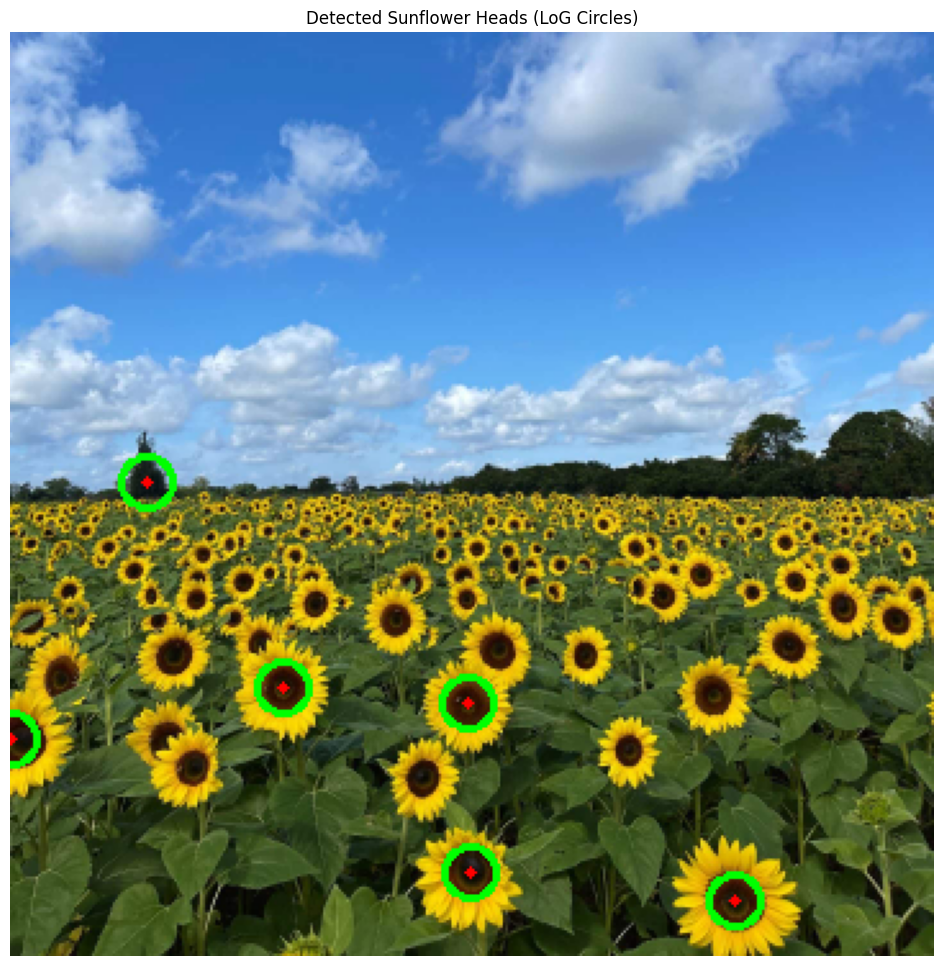


Top 5 Largest Circles:
1: Center=(53, 175), Radius=9.90 px
2: Center=(106, 255), Radius=9.90 px
3: Center=(178, 261), Radius=9.90 px
4: Center=(0, 275), Radius=9.90 px
5: Center=(179, 327), Radius=9.90 px

Sigma range used: 7 → 20


In [58]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
gray = gray.astype(np.float32) / 255.0


min_sigma = 7
max_sigma = 20
num_sigma = 100
sigmas = np.linspace(min_sigma, max_sigma, num_sigma)


scale_space = []
for sigma in sigmas:
    blur = cv.GaussianBlur(gray, (0, 0), sigma)
    log = cv.Laplacian(blur, cv.CV_32F, ksize=3)
    log = (sigma ** 2) * (log ** 2)  # scale normalization
    scale_space.append(log)

scale_space = np.stack(scale_space, axis=-1)

# Detect local maxima in 3D (x, y, σ) 
pad = 1
response = np.pad(scale_space, ((pad, pad), (pad, pad), (0, 0)), mode='constant')
blobs = []

threshold = 0.025 # sensitivity threshold
for i in range(1, response.shape[0] - 1):
    for j in range(1, response.shape[1] - 1):
        local_values = response[i-1:i+2, j-1:j+2, :]
        max_val = np.max(local_values)
        if max_val == response[i, j, :].max() and max_val > threshold:
            k = np.argmax(response[i, j, :])
            blobs.append((j - pad, i - pad, sigmas[k]))

# Convert σ to radius 
blobs = np.array(blobs)
if len(blobs) == 0:
    print("No blobs detected. Try lowering the threshold.")
else:
    blobs[:, 2] = np.sqrt(2) * blobs[:, 2]

# Draw round circles for detected blobs 
output = im.copy()
for (x, y, r) in blobs:
    r_int = max(1, int(round(r)))
    cv.circle(output, (int(x), int(y)), r_int, (0, 255, 0), 2)  # circle outline
    cv.circle(output, (int(x), int(y)), 2, (0, 0, 255), -1)    # red center dot


plt.figure(figsize=(12, 12))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Detected Sunflower Heads (LoG Circles)")
plt.axis('off')
plt.show()


if len(blobs) > 0:
    blobs = blobs[np.argsort(-blobs[:, 2])]
    largest = blobs[:5]
    print("\nTop 5 Largest Circles:")
    for i, (x, y, r) in enumerate(largest):
        print(f"{i+1}: Center=({int(x)}, {int(y)}), Radius={r:.2f} px")

print(f"\nSigma range used: {min_sigma} → {max_sigma}")
